In [31]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt


from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd

import time

from skimage.metrics import structural_similarity as ssim

In [32]:
# ==========================================
# 1. CONFIGURATION (UPDATE THESE PATHS!)
# ==========================================
TEMPLATE_IMAGE_PATH = 'data/template/birdseye_template.png'
TEMPLATE_POINTS_FILE = 'data/template/bird.txt'
TRAIN_IMAGES_DIR = 'data/train/images'
TRAIN_LABELS_DIR = 'data/train/points'
TEST_IMAGES_DIR = 'data/test/images'

In [33]:
# ==========================================
# 2. FEATURE EXTRACTION PIPELINE
# ==========================================

def create_roi_mask(img, h, w):
    """
    Generates a binary mask based on the yellow board line.
    """
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Finding Yellow Border Line
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([35, 255, 255])
    mask_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

    pts = cv2.findNonZero(mask_yellow)
    if pts is None or len(pts) < 50: return None

    pts = pts.squeeze()
    if pts.ndim == 1: pts = pts.reshape(-1, 2)
    xs, ys = pts[:, 0], pts[:, 1]

    try:
        # Fit a 2nd degree polynomial
        coeff = np.polyfit(xs, ys, 2)
        poly = np.poly1d(coeff)
    except: return None

    roi_mask = np.zeros((h, w), dtype=np.uint8)
    Y, X = np.ogrid[:h, :w]
    curve_y = poly(X)
    roi_mask[Y > curve_y] = 255
    return roi_mask

def extract_features_adaptive(img, visualize=False):
    """
    Extracts the 'Skeleton' of the rink lines.
    """
    if img is None: return None

    # 1. Filter & CLAHE
    img_blur = cv2.bilateralFilter(img, 9, 75, 75)
    lab = cv2.cvtColor(img_blur, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_eq = clahe.apply(l)

    # 2. Adaptive Threshold
    binary = cv2.adaptiveThreshold(l_eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 33, 4)

    # 3. ROI Mask (Remove Crowd)
    h, w = binary.shape
    dynamic_mask = create_roi_mask(img, h, w)
    if dynamic_mask is not None:
        binary = cv2.bitwise_and(binary, binary, mask=dynamic_mask)
    else:
        binary[0:int(h * 0.25), :] = 0

    # 4. Connected Components (Remove Player blobs/Noise)
    num, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    filtered_cc = np.zeros_like(binary)
    for i in range(1, num):
        # Filter small noise (skates, stick tape)
        if stats[i, cv2.CC_STAT_AREA] > 200:
            filtered_cc[labels == i] = 255

    # 5. Dilate (Thicken lines)
    kernel = np.ones((3,3), np.uint8)
    clean_skeleton = cv2.dilate(filtered_cc, kernel, iterations=1)

    if visualize:
        plt.figure(figsize=(10,5))
        plt.imshow(clean_skeleton, cmap='gray')
        plt.title("Extracted Features (Skeleton)")
        plt.axis('off'); plt.show()

    return clean_skeleton


# ==========================================
# 3. DATABASE
# ==========================================

def parse_keypoints(file_path):
    keypoints = {}
    if not os.path.exists(file_path): return keypoints
    with open(file_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip()
        if not line: continue
        parts = line.split()
        try:
            x, y = float(parts[-2]), float(parts[-1])
        except: continue
        raw_name = parts[:-2]
        clean_name = [p for p in raw_name if not (p.startswith('[') or p.endswith(']'))]
        name = "_".join(clean_name)
        if name: keypoints[name] = (x, y)
    return keypoints

def build_database(img_dir, lbl_dir):
    database = []
    image_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
    print(f"Building database from {len(image_paths)} images...")
    
    hog = cv2.HOGDescriptor()
    
    for i, img_path in enumerate(image_paths):
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, base_name + ".txt")
        if not os.path.exists(lbl_path): continue
            
        img = cv2.imread(img_path)
        if img is None: continue
        
        # Pre-calculate Skeleton here
        skeleton = extract_features_adaptive(img, visualize=False)

        small = cv2.resize(img, (64, 128))
        h = hog.compute(small).flatten()
        
        database.append({
            "name": base_name,
            "hog": h,
            "keypoints": parse_keypoints(lbl_path),
            "image": img,
            "skeleton": skeleton 
        })
    return database

def find_best_match(test_img, database):
    hog = cv2.HOGDescriptor()
    small = cv2.resize(test_img, (64, 128))
    test_hog = hog.compute(small).flatten()
    best_match, min_dist = None, float('inf')
    for record in database:
        dist = np.linalg.norm(test_hog - record['hog'])
        if dist < min_dist:
            min_dist = dist
            best_match = record
    return best_match


In [34]:

# ==========================================
# 4. SMART ALIGNMENT LOGIC (ECC)
# ==========================================

def refine_alignment_ecc(template_skeleton, test_skeleton, initial_warp):
    """
    Uses ECC to snap the training skeleton onto the test skeleton.
    """
    img1 = cv2.GaussianBlur(template_skeleton, (5, 5), 0).astype(np.float32) / 255.0
    img2 = cv2.GaussianBlur(test_skeleton, (5, 5), 0).astype(np.float32) / 255.0
    
    warp_mode = cv2.MOTION_HOMOGRAPHY
    warp_matrix = initial_warp.astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 500, 1e-5)

    print("Running ECC Refinement...")
    try:
        (cc, warp_matrix) = cv2.findTransformECC(img1, img2, warp_matrix, warp_mode, criteria)
        print(f"ECC Converged. Correlation: {cc:.4f}")
        return warp_matrix
    except cv2.error:
        print(f"ECC Failed to converge.")
        return initial_warp


def transfer_keypoints_smart(test_img, best_match, template_points):
    train_img = best_match['image']
    train_skel = best_match['skeleton']
    train_kps_dict = best_match['keypoints']

    # 1. Extract Skeleton (Raw Image)
    print("Extracting features...")
    test_skel = extract_features_adaptive(test_img, visualize=False)

    # 2. Masked SIFT (Using your RGB Mask Idea)
    masked_train_rgb = cv2.bitwise_and(train_img, train_img, mask=train_skel)
    masked_test_rgb = cv2.bitwise_and(test_img, test_img, mask=test_skel)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(masked_train_rgb, None)
    kp2, des2 = sift.detectAndCompute(masked_test_rgb, None)

    if kp1 is None or kp2 is None or len(kp1) < 5 or len(kp2) < 5: return [], [], None

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance: good.append(m)

    if len(good) < 4: return [], [], None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # 3. INITIAL ALIGNMENT (Affine Physics Constraint)
    # affine_matrix, _ = cv2.estimateAffinePartial2D(src_pts, dst_pts)
    affine_matrix = None

    if affine_matrix is None:
        H_init, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    else:
        H_init = np.vstack([affine_matrix, [0, 0, 1]])

    # 4. REFINEMENT (ECC)
    # Refine the match using the skeletons
    H_refined = refine_alignment_ecc(train_skel, test_skel, H_init)

    # 5. Transfer Points
    common = [k for k in train_kps_dict if k in template_points]
    if not common: return [], [], None

    pts_to_transfer = np.float32([train_kps_dict[k] for k in common]).reshape(-1, 1, 2)
    transferred = cv2.perspectiveTransform(pts_to_transfer, H_refined)

    final_src = transferred.reshape(-1, 2)
    return final_src, np.float32([template_points[k] for k in common]), H_refined


In [35]:
# ==========================================
# 5. VISUALIZATION HELPERS
# ==========================================

def visualize_match(test_img, match_img, match_name, test_name):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)); plt.title(f"Test: {test_name}"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)); plt.title(f"Match: {match_name}"); plt.axis('off')
    plt.tight_layout(); plt.show()

def visualize_test_on_train_overlay(test_img, train_img, H_train_to_test):
    """
    Warps the Test Image BACK onto the Training Image.
    This shows if the FIRST STEP (Transfer) worked correctly.
    """
    try:
        H_inv = np.linalg.inv(H_train_to_test)
    except: return
    h, w = train_img.shape[:2]
    warped_test = cv2.warpPerspective(test_img, H_inv, (w, h))
    
    gray_warped = cv2.cvtColor(warped_test, cv2.COLOR_BGR2GRAY)
    mask = cv2.threshold(gray_warped, 1, 255, cv2.THRESH_BINARY)[1]
    
    train_rgb = cv2.cvtColor(train_img, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped_test, cv2.COLOR_BGR2RGB)
    
    overlay = train_rgb.copy()
    overlay[mask==255] = cv2.addWeighted(train_rgb[mask==255], 0.5, warped_rgb[mask==255], 0.5, 0)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(overlay); plt.title("ALIGNMENT CHECK: Test Warped onto Train"); plt.axis('off'); plt.show()

def visualize_birdseye_overlay(test_img, template_path, H, img_name):
    if not os.path.exists(template_path): return
    template = cv2.cvtColor(cv2.imread(template_path), cv2.COLOR_BGR2RGB)
    h, w = template.shape[:2]
    warped = cv2.warpPerspective(test_img, H, (w, h))
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
    
    mask = cv2.threshold(cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)[1]
    
    template_faded = (template * 0.3).astype(np.uint8)
    overlay = template_faded.copy()
    overlay[mask==255] = cv2.addWeighted(template[mask==255], 0.2, warped_rgb[mask==255], 0.8, 0)
    base_name = os.path.basename(img_name)
    print(base_name)
    save_path = os.path.join("wraps", f"{base_name}")
    cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    
    plt.imshow(overlay); plt.title(img_name); plt.axis('off'); plt.show()


In [36]:
# ==========================================
# 6. MAIN
# ==========================================

print("Loading Template Points...")
template_dict = parse_keypoints(TEMPLATE_POINTS_FILE)

db = build_database(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)

test_H = {}
times = {}
for f in os.listdir(TEST_IMAGES_DIR):
    if f.endswith('.png') or f.endswith('.jpg'):
        img_path = os.path.join(TEST_IMAGES_DIR, f)
        print(f"\n--- Processing {f} ---")
        
        test_img = cv2.imread(img_path)
        if not db or test_img is None: continue

        # A. Find Match
        best_match = find_best_match(test_img, db)
        print(f"Closest Training Frame: {best_match['name']}")
        # visualize_match(test_img, best_match['image'], best_match['name'], f)

        # Start counting time
        start = time.perf_counter()
        
        # B. Smart Transfer
        src, dst, H_transfer = transfer_keypoints_smart(test_img, best_match, template_dict)

        if H_transfer is not None and len(src) >= 4:
            # C. Check Alignment (Test overlayed on Train)
            # visualize_test_on_train_overlay(test_img, best_match['image'], H_transfer)

            # D. Final Homography (Using RHO)
            H_final, _ = cv2.findHomography(src, dst, cv2.RHO, 3.0)
            
            # E. Final Result
            # visualize_birdseye_overlay(test_img, TEMPLATE_IMAGE_PATH, H_final, img_path)

            # F. store image and final H
            test_H[img_path] = H_final
        else:
            print("Failed to transfer points.")

        # End counting time 
        end = time.perf_counter()
        times[img_path] = end - start 
        


Loading Template Points...
Building database from 21 images...

--- Processing image1080.png ---
Closest Training Frame: image0
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.7038

--- Processing image241.png ---
Closest Training Frame: image0
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.6573

--- Processing image1439.png ---
Closest Training Frame: image30
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.6863

--- Processing image422.png ---
Closest Training Frame: image54
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.6024

--- Processing image287.png ---
Closest Training Frame: image1521
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.6437

--- Processing image293.png ---
Closest Training Frame: image18
Extracting features...
Running ECC Refinement...
ECC Converged. Correlation: 0.7355

--- Processing image307.png ---
Closest 

In [37]:
####################
## Evaluation
#####################

(-0.5, 1023.5, 447.5, -0.5)

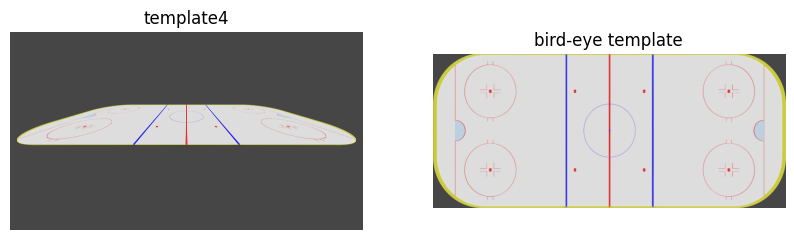

In [38]:
template_img = cv2.imread("data/template/template4.png")
template_img = cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)

bird_img = cv2.imread("data/template/birdseye_template.png")
bird_img = cv2.cvtColor(bird_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.imshow(template_img)
plt.title("template4")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bird_img)
plt.title("bird-eye template")
plt.axis("off")

In [39]:
def load_points_txt(path):
    pts = {}
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            name, x, y = line.split()
            pts[name] = (float(x), float(y))
    return pts


template_pts = load_points_txt("data/template/template4_points.txt")
bird_pts     = load_points_txt("data/template/birdseye_template_points.txt")

print("template points:", len(template_pts))
print("bird-eye points:", len(bird_pts))

template points: 101
bird-eye points: 21


In [40]:
common_keys = sorted(set(template_pts.keys()) & set(bird_pts.keys()))

In [41]:
src_pts = np.array(
    [template_pts[k] for k in common_keys],
    dtype=np.float32
)

dst_pts = np.array(
    [bird_pts[k] for k in common_keys],
    dtype=np.float32
)

In [42]:
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=5.0
)

(-0.5, 1023.5, 447.5, -0.5)

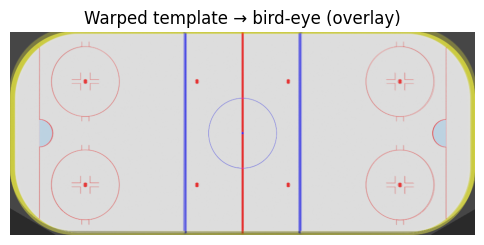

In [43]:
h, w, _ = bird_img.shape

warped = cv2.warpPerspective(
    template_img,
    H,
    (w, h)
)

overlay = cv2.addWeighted(bird_img, 0.6, warped, 0.4, 0)

plt.figure(figsize=(6,4))
plt.imshow(overlay)
plt.title("Warped template → bird-eye (overlay)")
plt.axis("off")

In [44]:
test_img_dir   = "data/test/images"
test_pts_dir   = "data/test/points"


In [45]:
image_files = sorted([
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Test images:", len(image_files))

Test images: 10


In [46]:
H_test_GD = {}

for img_name in image_files:

    print(f"\nProcessing {img_name}")

    img_path = os.path.join(test_img_dir, img_name)
    pts_path = os.path.join(
        test_pts_dir,
        os.path.splitext(img_name)[0] + ".txt"
    )

    if not os.path.exists(pts_path):
        print("  points file missing, skip")
        continue

    # --- load image ---
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- load test points ---
    test_pts = load_points_txt(pts_path)

    # --- find common points ---
    common_keys = sorted(
        set(test_pts.keys()) & set(template_pts.keys())
    )

    if len(common_keys) < 4:
        print("  not enough correspondences, skip")
        continue

    src_pts = np.array(
        [test_pts[k] for k in common_keys],
        dtype=np.float32
    )

    mid_pts = np.array(
        [template_pts[k] for k in common_keys],
        dtype=np.float32
    )

    # --- H: test -> template4 ---
    H_test_to_template, mask = cv2.findHomography(
        src_pts,
        mid_pts,
        cv2.RANSAC,
        5.0
    )

    if H_test_to_template is None:
        print("  homography failed")
        continue

    # --- compose H: test -> bird-eye ---
    H_test_to_be = H @ H_test_to_template

    # --- warp ---
    h_be, w_be, _ = bird_img.shape
    warped = cv2.warpPerspective(
        img,
        H_test_to_be,
        (w_be, h_be)
    )

    overlay = cv2.addWeighted(
        bird_img, 0.6,
        warped,   0.4,
        0
    )

    H_test_GD[img_path] = H_test_to_be

    # --- display ---
    # plt.figure(figsize=(8,4))
    # plt.imshow(overlay)
    # plt.title(f"{img_name} → bird-eye overlay")
    # plt.axis("off")

    # plt.show()


Processing image1080.png

Processing image1096.png

Processing image1439.png

Processing image241.png

Processing image287.png

Processing image293.png

Processing image307.png

Processing image350.png

Processing image422.png

Processing image466.png


In [47]:
def warp_to_birdeye(img, H, bird_shape):
    h, w = bird_shape[:2]
    return cv2.warpPerspective(img, H, (w, h))

In [48]:
def pixel_error(img1, img2, mask=None):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    if mask is not None:
        diff = diff[mask]
    l1 = np.mean(np.abs(diff))
    l2 = np.sqrt(np.mean(diff**2))
    return l1, l2

In [49]:
def ssim_score(img1, img2, mask=None):
    g1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    if mask is not None:
        return ssim(g1, g2, data_range=255)
    else:
        return ssim(g1, g2, data_range=255)

In [50]:
def valid_warp_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return gray > 0

In [51]:
results = []

for img_path in H_test_GD.keys():

    if img_path not in test_H:
        continue

    # if img_path == "data/test/images/image1096.png":
    #     continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # warp
    warp_gt   = warp_to_birdeye(img, H_test_GD[img_path], bird_img.shape)
    warp_pred = warp_to_birdeye(img, test_H[img_path], bird_img.shape)

    # valid region
    mask = valid_warp_mask(warp_gt) & valid_warp_mask(warp_pred)

    # metrics
    l1, l2 = pixel_error(warp_gt, warp_pred, mask)
    s      = ssim_score(warp_gt, warp_pred)

    results.append({
        "image": img_path,
        "L1": l1,
        "L2": l2,
        "SSIM": s
    })

print("Evaluated images:", len(results))

Evaluated images: 10


In [52]:
L1_vals   = [r["L1"] for r in results]
L2_vals   = [r["L2"] for r in results]
SSIM_vals = [r["SSIM"] for r in results]

print("Mean L1 :", np.mean(L1_vals))
print("Mean L2 :", np.mean(L2_vals))
print("Mean SSIM:", np.mean(SSIM_vals))

Mean L1 : 10.550812
Mean L2 : 27.163773
Mean SSIM: 0.9144270153874319


In [53]:
def visualize_difference(warp_gt, warp_pred):
    diff = cv2.absdiff(warp_gt, warp_pred)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)
    diff_norm = cv2.normalize(diff_gray, None, 0, 255, cv2.NORM_MINMAX)
    return diff_norm

(-0.5, 1023.5, 447.5, -0.5)

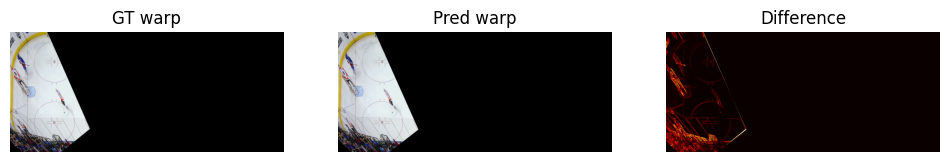

In [54]:
example = results[0]["image"]

img = cv2.imread(example)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

warp_gt   = warp_to_birdeye(img, H_test_GD[example], bird_img.shape)
warp_pred = warp_to_birdeye(img, test_H[example], bird_img.shape)

diff_vis = visualize_difference(warp_gt, warp_pred)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(warp_gt)
plt.title("GT warp")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(warp_pred)
plt.title("Pred warp")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(diff_vis, cmap="hot")
plt.title("Difference")
plt.axis("off")

In [55]:
def project_points(pts, H):
    """
    pts: (N,2)
    H:   (3,3)
    """
    pts = np.asarray(pts, dtype=np.float64)

    pts_h = np.hstack([
        pts,
        np.ones((pts.shape[0], 1))
    ])  # (N,3)

    proj = (H @ pts_h.T).T
    proj = proj[:, :2] / proj[:, 2:3]

    return proj

In [56]:
def reprojection_error_between_H(pts, H_gt, H_pred):
    """
    pts: (N,2) test image points
    """
    proj_gt   = project_points(pts, H_gt)
    proj_pred = project_points(pts, H_pred)

    errors = np.linalg.norm(proj_gt - proj_pred, axis=1)
    return errors

In [57]:
all_errors = []
each_errors = {}

for img_path in H_test_GD.keys():

    if img_path not in test_H:
        continue

    # if img_path == "data/test/images/image1096.png":
    #     continue

    pts_path = os.path.join(
        "data/test/points",
        os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    )

    if not os.path.exists(pts_path):
        continue

    test_pts_dict = load_points_txt(pts_path)
    test_pts = np.array(list(test_pts_dict.values()), dtype=np.float64)

    errs = reprojection_error_between_H(
        test_pts,
        H_test_GD[img_path],
        test_H[img_path]
    )



    each_errors[img_path] = errs
    all_errors.extend(errs)

In [58]:
all_errors = np.array(all_errors)

print("Reprojection error (px)")
print("Mean  :", all_errors.mean())
print("Median:", np.median(all_errors))
print("Std   :", all_errors.std())
print("Max   :", all_errors.max())

Reprojection error (px)
Mean  : 1.7091374752148982
Median: 1.2268524143765418
Std   : 1.6840863755998117
Max   : 14.256727714299874


In [59]:
print(each_errors)

{'HockeyHomographyTest/test/images/image1080.png': array([1.15764033, 1.91046933, 1.42492939, 1.40886242, 0.87257084,
       0.32783141, 0.3566636 , 0.88014209, 0.90444603, 1.41628463,
       1.421814  , 1.89265366, 1.03152685, 1.03486911, 1.33787387,
       1.32896652, 0.8209619 , 1.14814645, 1.30184072, 1.21009383,
       1.22045859, 1.0517695 , 1.06472082, 1.07552912, 1.09598525,
       1.20807265, 1.20719544, 1.28629502, 1.26526808, 1.27248456,
       1.06040395, 1.05345493]), 'HockeyHomographyTest/test/images/image1096.png': array([0.26935467, 4.2777809 , 4.15353047, 0.34714893, 0.42490747,
       0.0608578 , 0.15874196, 0.4917921 , 0.60589367, 1.15538096,
       1.25504105, 0.71995561, 0.88758725, 0.29836318, 0.12760834,
       0.36408912, 0.48500698, 0.51147599, 1.8518023 , 1.41462544]), 'HockeyHomographyTest/test/images/image1439.png': array([1.28778349, 2.6013466 , 1.83893956, 2.2982572 , 1.52127598,
       0.99926442, 0.26041323, 0.09142847, 0.68901694, 0.37555954,
       1.2

In [60]:
for img_path in each_errors.keys():
    print(img_path)
    print("Reprojection error (px)")
    print("Mean  :", each_errors[img_path].mean())
    print("Median:", np.median(each_errors[img_path]))
    print("Std   :", each_errors[img_path].std())
    print("Max   :", each_errors[img_path].max())

HockeyHomographyTest/test/images/image1080.png
Reprojection error (px)
Mean  : 1.1578195270741607
Median: 1.1824178834880081
Std   : 0.3192533888831833
Max   : 1.9104693250245735
HockeyHomographyTest/test/images/image1096.png
Reprojection error (px)
Mean  : 0.9930472081932138
Median: 0.501634043822244
Std   : 1.166642011273002
Max   : 4.277780895240215
HockeyHomographyTest/test/images/image1439.png
Reprojection error (px)
Mean  : 1.9993866495681083
Median: 1.4050247227403632
Std   : 1.8514164591006965
Max   : 7.491161606030303
HockeyHomographyTest/test/images/image241.png
Reprojection error (px)
Mean  : 1.649253488413419
Median: 1.5173514553833345
Std   : 0.5360063840941495
Max   : 2.686225694964644
HockeyHomographyTest/test/images/image287.png
Reprojection error (px)
Mean  : 2.235469708926064
Median: 1.0470668183704794
Std   : 2.9443330596566804
Max   : 14.256727714299874
HockeyHomographyTest/test/images/image293.png
Reprojection error (px)
Mean  : 1.4320556677754064
Median: 1.0195621

In [61]:
print(H_test_GD)

{'HockeyHomographyTest/test/images/image1080.png': array([[-9.56539470e-02, -2.86538913e-01,  2.06707074e+02],
       [ 6.63027108e-02, -4.87494597e-01,  5.24599821e+01],
       [-1.93139058e-05, -5.16636004e-04, -3.64840598e-01]]), 'HockeyHomographyTest/test/images/image1096.png': array([[-8.67751717e-02, -1.88208177e-01, -1.14770221e+02],
       [-2.12498987e-02, -3.43582420e-01,  1.58241217e+02],
       [-1.12090308e-05, -3.78218813e-04, -2.09747771e-01]]), 'HockeyHomographyTest/test/images/image1439.png': array([[-5.39623856e-02, -1.44302184e-01, -2.57134160e+02],
       [-3.68944289e-02, -3.07259280e-01,  1.39727659e+02],
       [ 7.21350292e-06, -3.14947699e-04, -2.36326973e-01]]), 'HockeyHomographyTest/test/images/image241.png': array([[-7.41425841e-02, -2.36499240e-01,  1.72738438e+02],
       [ 6.35650293e-02, -3.99696252e-01,  5.14621220e+00],
       [ 1.46054198e-06, -4.22406255e-04, -4.33705023e-01]]), 'HockeyHomographyTest/test/images/image287.png': array([[-8.91878753e-02

In [62]:
print(test_H)

{'HockeyHomographyTest/test/images/image1080.png': array([[ 2.45394200e-01,  7.36919761e-01, -5.30389343e+02],
       [-1.70503214e-01,  1.25401950e+00, -1.34512115e+02],
       [ 3.41422674e-05,  1.28472270e-03,  1.00000000e+00]]), 'HockeyHomographyTest/test/images/image241.png': array([[ 1.91121444e-01,  5.83237171e-01, -4.40975800e+02],
       [-1.35033458e-01,  9.92915094e-01, -5.58080177e+01],
       [ 4.55959344e-05,  1.02908572e-03,  1.00000000e+00]]), 'HockeyHomographyTest/test/images/image1439.png': array([[ 3.14220488e-01,  7.07107306e-01,  1.10908875e+03],
       [ 2.02214643e-01,  1.39545310e+00, -6.49968506e+02],
       [ 3.75330783e-05,  1.50683685e-03,  1.00000000e+00]]), 'HockeyHomographyTest/test/images/image422.png': array([[ 1.80155352e-01,  5.22168994e-01, -2.92869690e+02],
       [-1.14625007e-01,  8.92137885e-01, -1.74917831e+02],
       [-3.65834640e-05,  9.59110330e-04,  1.00000000e+00]]), 'HockeyHomographyTest/test/images/image287.png': array([[ 3.15878242e-01,

In [63]:
print(len(each_errors))

10


In [64]:
print(times)

{'HockeyHomographyTest/test/images/image1080.png': 1.135242512998957, 'HockeyHomographyTest/test/images/image241.png': 1.0192611050006235, 'HockeyHomographyTest/test/images/image1439.png': 0.8608193649997702, 'HockeyHomographyTest/test/images/image422.png': 1.6457522019991302, 'HockeyHomographyTest/test/images/image287.png': 1.020620194998628, 'HockeyHomographyTest/test/images/image293.png': 0.8129211560008116, 'HockeyHomographyTest/test/images/image307.png': 0.8974597929991432, 'HockeyHomographyTest/test/images/image1096.png': 0.8966098820019397, 'HockeyHomographyTest/test/images/image466.png': 0.70394175200272, 'HockeyHomographyTest/test/images/image350.png': 0.7601393900004041}


In [65]:
for img in times.keys():
    print(img + ": " + str(times[img]))

HockeyHomographyTest/test/images/image1080.png: 1.135242512998957
HockeyHomographyTest/test/images/image241.png: 1.0192611050006235
HockeyHomographyTest/test/images/image1439.png: 0.8608193649997702
HockeyHomographyTest/test/images/image422.png: 1.6457522019991302
HockeyHomographyTest/test/images/image287.png: 1.020620194998628
HockeyHomographyTest/test/images/image293.png: 0.8129211560008116
HockeyHomographyTest/test/images/image307.png: 0.8974597929991432
HockeyHomographyTest/test/images/image1096.png: 0.8966098820019397
HockeyHomographyTest/test/images/image466.png: 0.70394175200272
HockeyHomographyTest/test/images/image350.png: 0.7601393900004041
